In [1]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
Pkg.resolve()

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts`
  No Changes to `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/Project.toml`
  No Changes to `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/Manifest.toml`


In [2]:
using Distributions
using LinearAlgebra
using StatsFuns
using StatsBase

using LogDensityProblems
using LogDensityProblemsAD
using AbstractDifferentiation
using MCMCDiagnosticTools
using AdvancedHMC
using MicroCanonicalHMC
using Pathfinder
using Transducers

using Healpix
using HealpixMPI
using MPI

using Plots
using StatsPlots
using LaTeXStrings
using DataFrames

using Random
using ProgressMeter
using BenchmarkTools
using NPZ
using CSV
using Test

using Zygote: @adjoint
using Zygote
using ChainRules.ChainRulesCore

include("AD_parallSHT.jl")
include("gen_datatest.jl")
include("reparam.jl")
include("utils.jl")
include("inference_model.jl")
include("neglogproblem.jl")

nℓπ_grad (generic function with 1 method)

In [3]:
# using Turing
# using Capse
using NPZ
# # using PlanckLite
# using BenchmarkTools
# using Plots
# using Optim
# using ForwardDiff
# using Pathfinder
# #using MicroCanonicalHMC
# #using Transducers
# using StatsPlots
# #using PairPlots
# #using LaTeXStrings
# #using CairoMakie
# using MCMCChains
using PSIS
# include("utils.jl");
using ArviZ
#using ArviZPythonPlots
using LinearAlgebra
using IrrationalConstants
using DimensionalData
using Statistics

In [4]:
Threads.nthreads()

4

In [5]:
# files = filter(
#     f -> endswith(f, "_mask_NUTS_nside_16.npy"),
#     readdir("/Users/ethansmith/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/MPI_chains"; join=true)
# )

# for file in files
#     println(file)
# end

# sort!(files)

# sampled_params = hcat((npzread(f) for f in files)...)

files = ["/Users/ethansmith/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/MPI_chains/frxOb_mask_NUTS_nside_16.npy"]
sampled_params = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/MPI_chains/frxOb_mask_NUTS_nside_16.npy")

samples = size(sampled_params, 2)

2000

In [6]:
ids = [
    replace(splitext(basename(f))[1],
            "_mask_NUTS_nside_16" => "")
    for f in files
]

runname = join(ids, "_")

"frxOb"

In [7]:
seed = 1123
Random.seed!(seed)

#   RESOLUTION PARAMETERS
nside = 16
lmax = 2*nside - 1

MPI.Init()

comm = MPI.COMM_WORLD
crank = MPI.Comm_rank(comm)
csize = MPI.Comm_size(comm)
root = 0
ncore = 32

#   REALIZATION MAP
realiz_Cl, realiz_HAlm, realiz_HMap = Realization("Capse_fiducial_Dl.csv", nside, lmax, seed)
realiz_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([realiz_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(realiz_Cl))

d = length(realiz_θ)

#   SURVEY MASK
mask_512 = readMapFromFITS("wmap_temperature_kq85_analysis_mask_r9_9yr_v5.fits",2,Float64)
mask_nside = udgrade(nest2ring(mask_512), nside)
for i in 1:length(mask_nside.pixels)
    if mask_nside.pixels[i]<=0.5
        mask_nside.pixels[i]=1
    else
        mask_nside.pixels[i]=0
    end
end

#   GENERATED DATA MEASUREMENTS
#   Noise
ϵ=150
N = ϵ*ones(nside2npix(nside))
N[mask_nside.==1] .= 5*10^4
#   Gaussian beam and pixel window function
Bl = ones(length(realiz_Cl))#gaussbeam(0.001, lmax, pol=false)
Pl = ones(length(realiz_Cl))#pixwin(nside, pol=false)[1:lmax+1]
BP_l = Bl.*Pl

#   Data Map
gen_Cl, gen_HAlm, gen_HMap = Measurement(realiz_Cl, Bl, Pl, mask_nside, N, nside, lmax, seed)
gen_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([gen_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(gen_Cl))
invN_HMap = HealpixMap{Float64,RingOrder}(1 ./ N)

#   STARTING POINT
start_Cl, start_HAlm, start_HMap = StartingPoint(gen_Cl, nside)
start_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([start_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(start_Cl))

#   PROMOTE HEALPIX.MAP TO HEALIPIXMPI.DMAP
gen_DMap = DMap{RR}(comm)
invN_DMap = DMap{RR}(comm)
HealpixMPI.Scatter!(gen_HMap, gen_DMap, comm, clear=true)
HealpixMPI.Scatter!(invN_HMap, invN_DMap, comm, clear=true)

helper_DMap = deepcopy(gen_DMap)

DMap: I am task 0 of 1, I work on 63 rings of 63
DMap: I am task 0 of 1, I work on 63 rings of 63


DMap{RR, Float64}([0.0; 0.0; … ; 106.75576281525872; 57.76576547614584;;], GeomInfoMPI(MPI.Comm(1140850688), 16, 64, [1.5707963267948966, 1.5291175943723188, 1.6124750592174744, 1.4873662401842815, 1.6542264134055116, 1.445468495626831, 1.696124157962962, 1.4033482475752073, 1.7382444060145859, 1.3609257345321588  …  0.25585245340993723, 2.885740200179856, 0.20448019896853478, 2.9371124546212584, 0.15324300949611616, 2.988349644093677, 0.10210642238260403, 3.039486231207189, 0.05103657515266638, 3.090556078437127], [32, 31, 33, 30, 34, 29, 35, 28, 36, 27  …  5, 59, 4, 60, 3, 61, 2, 62, 1, 63], [1, 65, 129, 193, 257, 321, 385, 449, 513, 577  …  2953, 2973, 2993, 3009, 3025, 3037, 3049, 3057, 3065, 3069], [64, 64, 64, 64, 64, 64, 64, 64, 64, 64  …  20, 20, 16, 16, 12, 12, 8, 8, 4, 4], [1.5707963267948966, 1.5291175943723188, 1.6124750592174744, 1.4873662401842815, 1.6542264134055116, 1.445468495626831, 1.696124157962962, 1.4033482475752073, 1.7382444060145859, 1.3609257345321588  …  0.25

In [8]:
# θ = sampled_params[:,1]
# alm = θ[1:length(θ)-lmax-1]
# sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)
# sample_HAlm = from_alm_to_healpix_alm(sample_alm, lmax, 1, comm, root=root)[1]
# sample_DAlm = HAlm2DAlm(sample_HAlm, comm; clear=true, root=root)

In [9]:
# NLL_Pixel(sample_DAlm, helper_DMap, ncore, gen_DMap, invN_DMap, BP_l, 1354)

In [10]:
pixels = length(gen_DMap.pixels)

3072

In [11]:
NLLs = Matrix{Any}(undef, pixels, samples)

for n in 1:samples
    θ = sampled_params[:,n]
    alm = θ[1:length(θ)-lmax-1]
    sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)
    sample_HAlm = from_alm_to_healpix_alm(sample_alm, lmax, 1, comm, root=root)[1]
    sample_DAlm = HAlm2DAlm(sample_HAlm, comm; clear=true, root=root)

    Threads.@threads for i in 1:pixels
        NLL = NLL_Pixel(sample_DAlm, helper_DMap, ncore, gen_DMap, invN_DMap, BP_l, i)
        NLLs[i,n] = NLL
    end
end

DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am ta

In [12]:
NLLs

3072×2000 Matrix{Any}:
  nothing      nothing      nothing     …   nothing     nothing     nothing
  nothing      nothing      nothing         nothing     nothing     nothing
  nothing      nothing      nothing         nothing     nothing     nothing
  nothing      nothing      nothing         nothing     nothing     nothing
  nothing      nothing      nothing         nothing     nothing     nothing
  nothing      nothing      nothing     …   nothing     nothing     nothing
  nothing      nothing      nothing         nothing     nothing     nothing
  nothing      nothing      nothing         nothing     nothing     nothing
  nothing      nothing      nothing         nothing     nothing     nothing
  nothing      nothing      nothing         nothing     nothing     nothing
  nothing      nothing      nothing     …   nothing     nothing     nothing
  nothing      nothing      nothing         nothing     nothing     nothing
  nothing      nothing      nothing         nothing     nothing  

In [13]:
function count_nothings(NLLs, pixels, samples)
    nothing_count = 0
    something_count = 0

    for i in 1:pixels
        for j in 1:samples
            if NLLs[i,j] === nothing
                nothing_count += 1
            else
                something_count += 1
            end
        end
    end

    return nothing_count, something_count
end

nothing_count, something_count = count_nothings(NLLs, pixels, samples)

println(nothing_count)
println(something_count)

1376000
4768000


In [14]:
switch_vector = Vector{Int64}()
for i in 1:(pixels-1)
    if (NLLs[i,1] == nothing && NLLs[i+1, 1] != nothing) || (NLLs[i,1] != nothing && NLLs[i+1, 1] == nothing)
        append!(switch_vector, i)
    end
end
println(length(switch_vector))
println(switch_vector)

261
[29, 30, 96, 97, 102, 104, 105, 106, 107, 108, 157, 158, 220, 224, 226, 234, 236, 238, 241, 242, 273, 275, 279, 281, 284, 285, 331, 332, 348, 368, 369, 371, 372, 373, 392, 394, 402, 405, 407, 410, 411, 413, 415, 416, 418, 423, 454, 455, 457, 465, 476, 486, 487, 491, 493, 495, 496, 502, 518, 519, 520, 522, 524, 527, 529, 540, 545, 546, 549, 553, 561, 562, 563, 566, 582, 595, 597, 599, 600, 601, 603, 620, 622, 624, 625, 632, 643, 644, 645, 650, 651, 657, 658, 668, 679, 681, 683, 684, 689, 695, 697, 698, 708, 709, 710, 723, 724, 748, 752, 761, 769, 772, 773, 777, 778, 784, 785, 795, 797, 798, 801, 802, 807, 809, 810, 812, 817, 825, 830, 832, 836, 837, 838, 851, 853, 877, 880, 887, 888, 890, 893, 894, 896, 897, 898, 913, 914, 924, 925, 926, 931, 932, 935, 941, 945, 955, 956, 960, 964, 965, 966, 979, 980, 1005, 1007, 1015, 1016, 1017, 1018, 1019, 1024, 1025, 1026, 1052, 1053, 1054, 1058, 1060, 1063, 1068, 1073, 1083, 1084, 1088, 1092, 1093, 1095, 1134, 1136, 1143, 1144, 1148, 1152, 1183

In [15]:
unmasked_pixels = 0
for i in 1:pixels
    if NLLs[i, 1] !== nothing
        global unmasked_pixels += 1
    end
end

unmasked_NLLs = Matrix{Float64}(undef, unmasked_pixels, samples)
unmasked_pixels = 0
for i in 1:pixels
    if NLLs[i, 1] !== nothing
        global unmasked_pixels += 1
        unmasked_NLLs[unmasked_pixels,:] = NLLs[i,:]
    end
end

In [16]:
unmasked_pixels

2384

In [17]:
unmasked_NLLs

2384×2000 Matrix{Float64}:
 0.728286     0.725924     0.746523     …  0.380831    0.38232     0.374707
 0.226021     0.234749     0.21968         0.109733    0.105087    0.105244
 0.000723927  0.0016375    0.0018122       0.00195404  0.00113865  0.00276261
 1.28665      1.29837      1.31642         2.4876      2.49997     2.5164
 1.85141      1.85906      1.87302         1.53671     1.52872     1.52619
 0.242979     0.241816     0.24567      …  1.15798     1.12043     1.10922
 0.0338094    0.033329     0.0340125       0.0670542   0.0732291   0.0715165
 0.632894     0.643553     0.633815        0.519404    0.528083    0.541697
 0.0869057    0.0862926    0.0920107       0.0440724   0.0436595   0.0391231
 0.506443     0.509404     0.51141         0.279001    0.276996    0.286909
 0.023231     0.0217752    0.0249389    …  6.34701e-6  4.57495e-5  1.41951e-8
 0.116047     0.108691     0.106028        0.0877619   0.0894444   0.0954909
 0.381997     0.389298     0.403312        0.57689     0.5

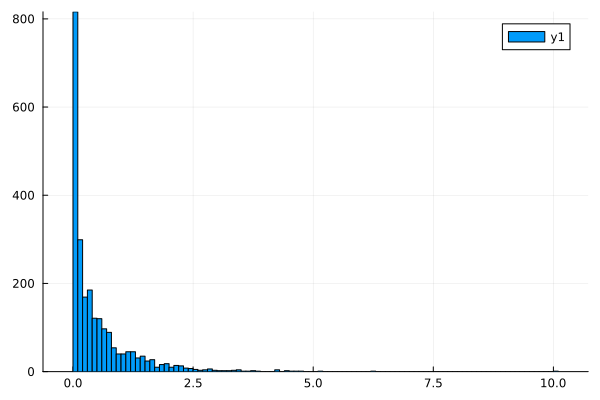

In [18]:
histogram(unmasked_NLLs[:,1])

In [19]:
psis_result = Vector{PSISResult{Float64, Vector{Float64}, Int64, Int64, PSIS.GeneralizedPareto{Float64}}}(undef, unmasked_pixels);
for i in 1:unmasked_pixels
    psis_result[i] = psis(unmasked_NLLs[i,:])
end

┌ Warning: Pareto shape k = 0.84 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:365
┌ Warning: Pareto shape k = 0.75 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:365


Pareto Shapes: [-0.31308074541688796, -0.310111914765791, -0.2808185534404063, -0.46192919271378335, -0.32417653974869276, -0.7168260758573641, -0.43879235517735343, -0.22298440985601586, -0.10975773951268686, 0.03417579340100348, -0.2973568283440717, -0.22106977092597452, -0.5891507156918946, -0.44493736042978055, -0.2358945314454815, -0.24378190607747777, -0.459403326089063, -0.4614683115489419, -0.24511974721232885, -0.36883836405134324, -0.47076574397373, -0.18812839684005256, -0.4706547416956699, -0.3847853520174364, -0.09809772753614972, -0.1687029526156325, -0.4865353195690759, 0.2638365195832288, -0.21769960487815795, -0.23283528540455978, -0.18222720665384642, 0.1550992646277565, -0.4429321635829922, -0.23464776039720878, -0.277787154388263, -0.02430056796447119, -0.450010839262155, -0.31255202463131515, -0.8443325245629762, -0.3819482940661283, -0.550321068908238, -0.625857313999851, -0.23870520449325963, -0.3972253353164755, -0.17604720160559156, -0.13908046332289273, -0.548

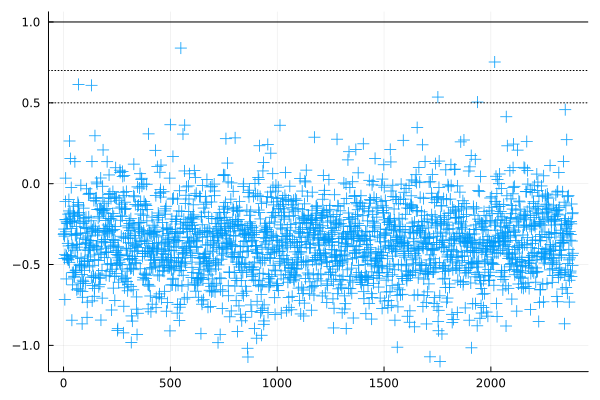

In [20]:
pareto_shapes = Vector{Float64}()
for i in 1:unmasked_pixels
    append!(pareto_shapes, psis_result[i].pareto_shape)
end
println("Pareto Shapes: ", pareto_shapes)

shape_plot = Plots.scatter(pareto_shapes; marker =:+, markersize=6, legend = false, linewidth=2)
hline!([0.5,0.7], linestyle=:dot, color =:black)
hline!([1.0], linestyle=:solid, color=:black)

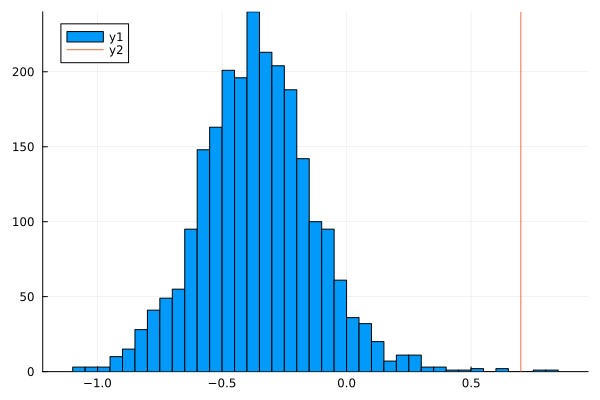

In [21]:
psis_shapes_hist = histogram(pareto_shapes)
vline!([0.7])

In [22]:
failure_count= 0 
for i in 1:unmasked_pixels
    if pareto_shapes[i] > 0.7
        global failure_count += 1
    end
end
failure_rate = failure_count / unmasked_pixels
println(failure_count)
println(failure_rate)

2
0.0008389261744966443


In [23]:
mkpath("PSIS_results/$(samples)_$(nside)/$runname")
npzwrite("PSIS_results/$(samples)_$(nside)/$runname/pareto_shapes.npy", pareto_shapes)
npzwrite("PSIS_results/$(samples)_$(nside)/$runname/failure_rate.npy", [failure_count, unmasked_pixels, failure_rate])
Plots.savefig(shape_plot, "PSIS_results/$(samples)_$(nside)/$runname/pareto_shapes.png")
Plots.savefig(psis_shapes_hist, "PSIS_results/$(samples)_$(nside)/$runname/pareto_shapes_histogram.png")

"/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/PSIS_results/2000_16/frxOb/pareto_shapes_histogram.png"

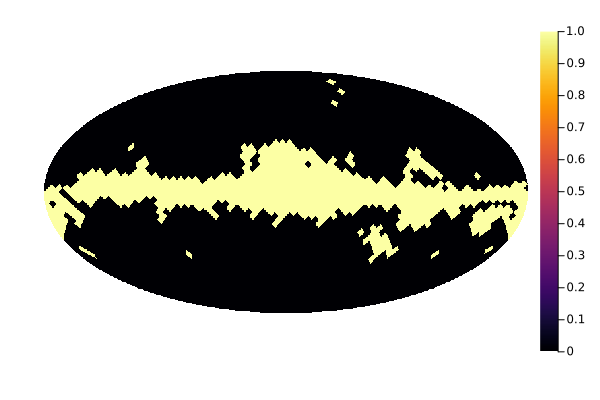

In [24]:
plot(mask_nside)

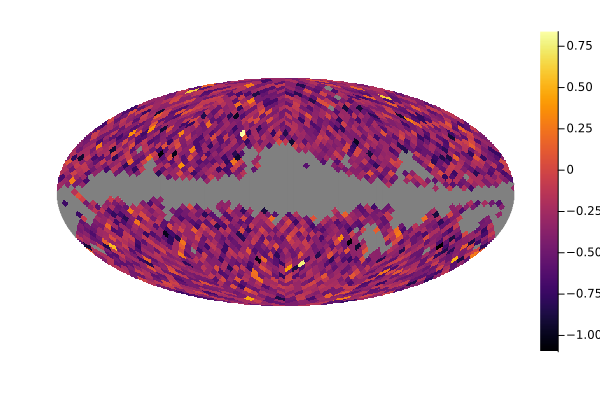

In [25]:
shape_mapping = deepcopy(mask_nside)

unmasked_index = 0
for pix in 1:pixels
    if shape_mapping[pix] != 1.0
        global unmasked_index += 1
        shape_mapping[pix] = pareto_shapes[unmasked_index]
    else
        shape_mapping[pix] = NaN
    end
end

shape_map = plot(shape_mapping)

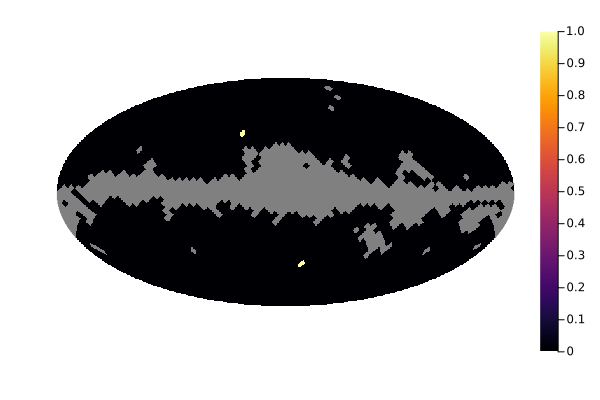

In [26]:
failure_mapping = deepcopy(mask_nside)

unmasked_index = 0
for pix in 1:pixels
    if failure_mapping[pix] != 1.0
        unmasked_index += 1
        if pareto_shapes[unmasked_index] > 0.7
            failure_mapping[pix] = 1.0
        else
            failure_mapping[pix] = 0.0
        end
    else
        failure_mapping[pix] = NaN
    end
end

failure_map = Plots.plot(failure_mapping)

In [27]:
Plots.savefig(failure_map, "PSIS_results/$(samples)_$(nside)/$runname/failure_map.png")
Plots.savefig(shape_map, "PSIS_results/$(samples)_$(nside)/$runname/shape_map.png")

"/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/PSIS_results/2000_16/frxOb/shape_map.png"

### PIT
Work in progress

In [28]:
θ = sampled_params[:,1]
alm = θ[1:length(θ)-lmax-1]
sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)
sample_HAlm = from_alm_to_healpix_alm(sample_alm, lmax, 1, comm, root=root)[1]
sample_DAlm = HAlm2DAlm(sample_HAlm, comm; clear=true, root=root)

DAlm: I am task 0 of 1, I work on 32 m's of 31


DAlm{RR, ComplexF64}(ComplexF64[-1.1543791582249528e-6 + 0.0im; -4.579322377774118e-6 + 0.0im; … ; 5.588839026346115 - 0.06774390349989039im; 0.4415137020459905 - 0.7601156300628327im;;], AlmInfoMPI(MPI.Comm(1140850688), 31, 31, 32, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9  …  22, 23, 24, 25, 26, 27, 28, 29, 30, 31], [1, 32, 62, 91, 119, 146, 172, 197, 221, 244  …  452, 461, 469, 476, 482, 487, 491, 494, 496, 497]))